# **RAGAS**

Ragas is a library that helps you move from "vibe checks" to **systematic evaluation loops** for your AI applications.

It provides tools to supercharge the evaluation of LLM applications, enabling you to evaluate your LLM applications with ease and confidence.

### **Why Ragas?**

Traditional evaluation metrics don't capture what matters for LLM applications. Manual evaluation doesn't scale. Ragas solves this by combining LLM-driven metrics with systematic experimentation to create a continuous improvement loop.

### **Key Features**

- **Experiments-first approach:** Evaluate changes consistently with experiments. Make changes, run evaluations, observe results, and iterate to improve your LLM application.

- **Ragas Metrics:** Create custom metrics tailored to your specific use case with simple decorators or use our **library of available metrics**.

- **Easy to integrate:** Built-in dataset management, result tracking, and integration with popular frameworks like LangChain, LlamaIndex, and more.


References:

- [Introduction to RAGAS](https://docs.ragas.io/en/stable/)

- [List of Available Metrics](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/)

- To learn more about metrics in Ragas, refer [here](https://docs.ragas.io/en/stable/concepts/metrics/overview/).

### Install Dependencies

In [ ]:
%%capture
!pip -q install openai==2.7.1
!pip -q install langchain==1.0.5
!pip -q install langchain-openai==1.0.2
!pip -q install langchain-community==0.4.1
!pip -q install langchain-core==1.4.6
!pip -q install langchain-experimental==0.0.42
!pip -q install langchain-huggingface==1.0.1
!pip -q install langchainhub==0.1.21
!pip -q install langgraph==1.0.10
!pip -q install ragas==0.2.15

### Read the OpenAI API Key

In [3]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')           # In using OpenAI model

### **Get Started with RAGAS evaluation**

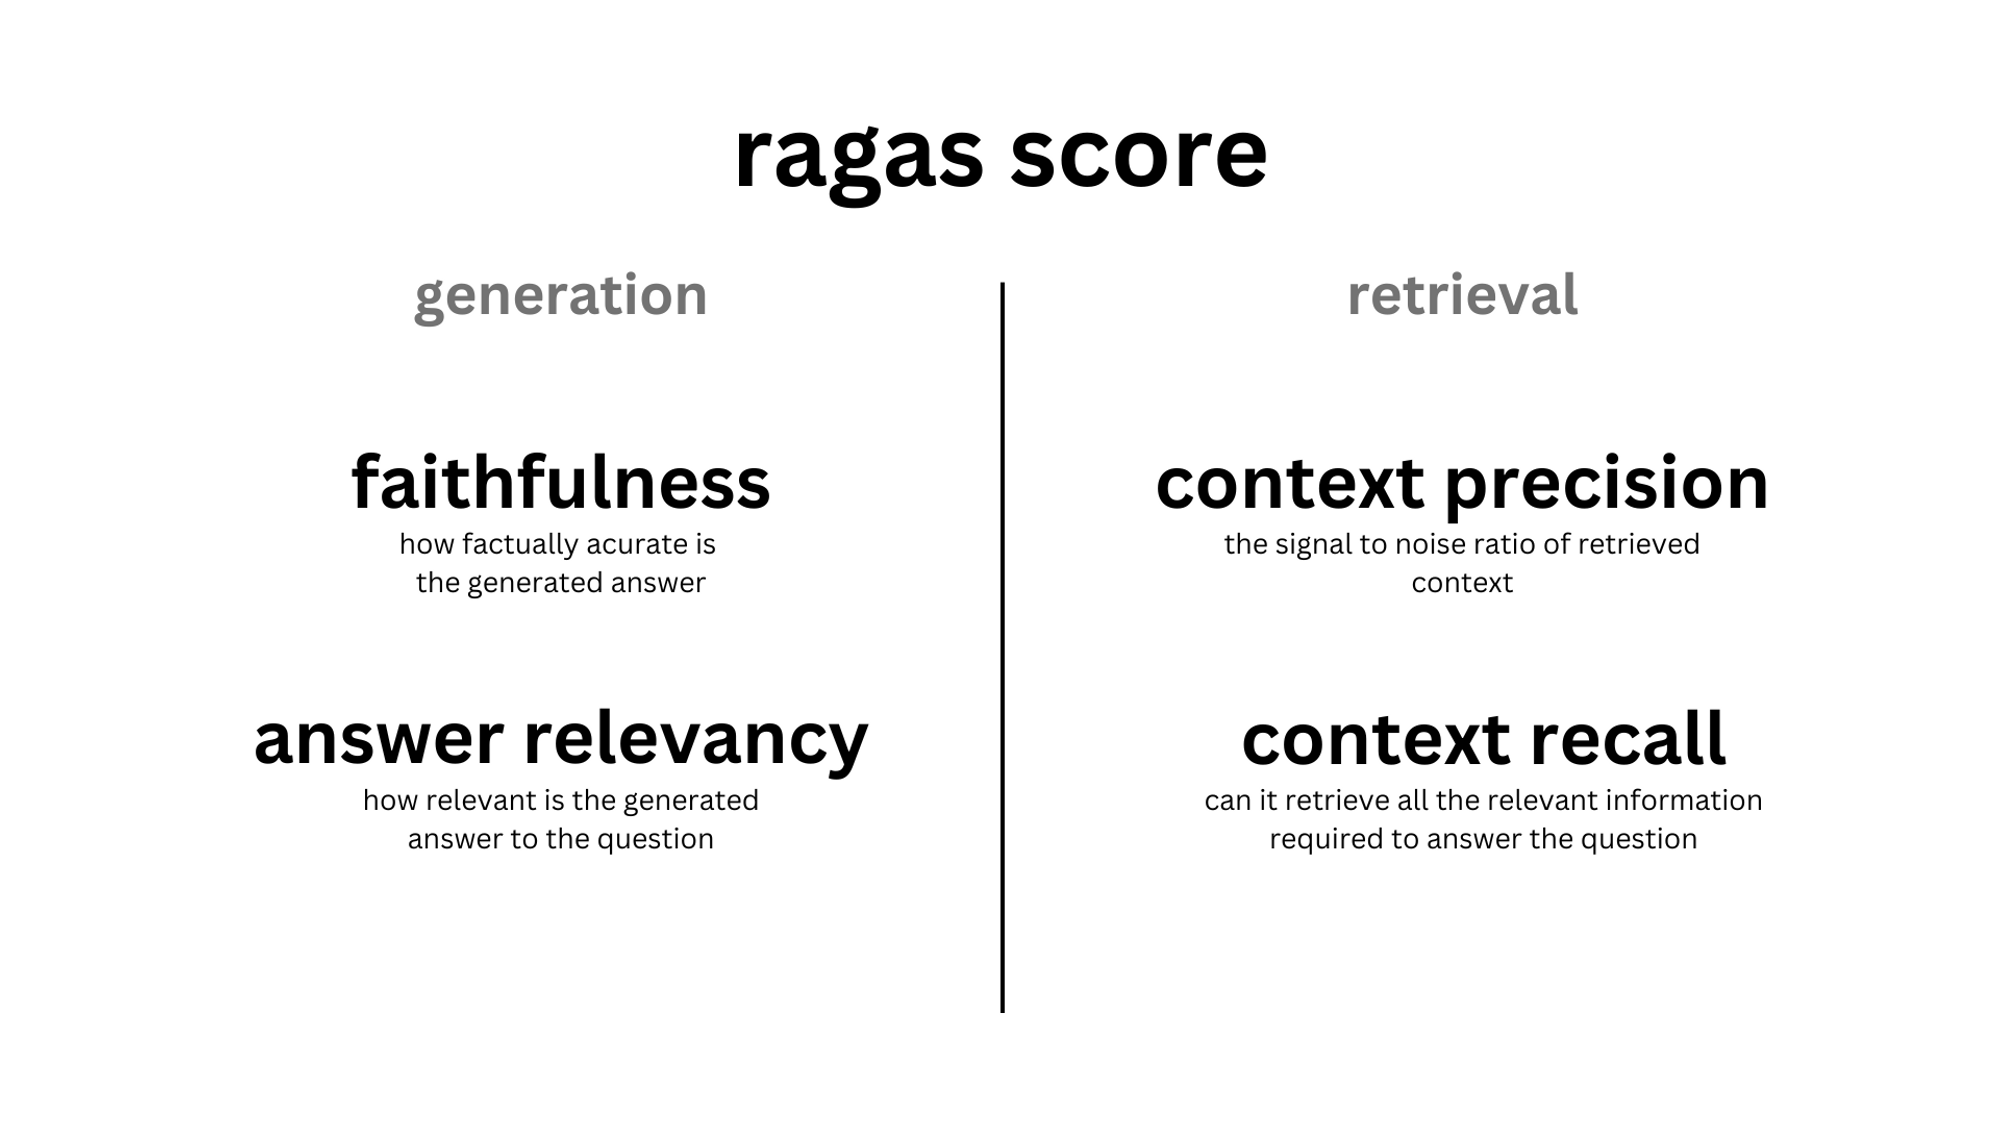

In [2]:
# Import Dataset to create a RAGAS-compatible evaluation dataset
from datasets import Dataset

# Import `evaluate` function to run RAGAS evaluation on the dataset
from ragas import evaluate

# Import RAGAS metrics for evaluating different aspects of RAG performance
from ragas.metrics import (
    faithfulness,        # Checks whether the answer is grounded in the retrieved context
    answer_relevancy,    # Checks whether the answer is relevant to the user question
    context_precision,   # Checks whether the retrieved contexts are relevant and ranked properly
    context_recall,      # Checks whether the retrieved contexts contain the required information
)

In [7]:
# Create a RAGAS evaluation dataset with multiple user queries
# Each record contains:
# 1. question      - user input query
# 2. answer        - response generated by the RAG application
# 3. contexts      - retrieved document chunks used to generate the answer
# 4. ground_truth  - expected/reference answer

data = {
    # List of user queries to evaluate
    "question": [
        "Which colors are available?",
        "Is XSound Pro water-resistant?",
        "What is included in the box?"
    ],

    # Answers generated by the LLM or RAG pipeline for each user query
    "answer": [
        "The XSound Pro headphones are available in Black, Silver, and Midnight Blue.",
        "Yes, XSound Pro has an IPX4 splash-resistance rating. It can handle light rain and sweat but is not waterproof.",
        "The box includes XSound Pro Headphones, USB-C charging cable, 3.5mm audio cable, travel case, and quick start guide."
    ],

    # Retrieved contexts for each query
    # Each question can have one or more retrieved context chunks
    "contexts": [
        [
            "Q1. What colors are available? A. XSound Pro is available in three finishes: Black, Silver, and Midnight Blue.",
            "Q2. Is it water-resistant? A. The headphones have an IPX4 splash-resistance rating, meaning they can withstand light rain and sweat, but they are not waterproof.",
            "Q3. What is included in the box? A. Box contents include: XSound Pro Headphones, USB-C charging cable, 3.5mm audio cable, Travel case, Quick start guide."
        ],
        [
            "Q2. Is it water-resistant? A. The headphones have an IPX4 splash-resistance rating, meaning they can withstand light rain and sweat, but they are not waterproof.",
            "Warranty & Support: Not Covered: Physical damage, water immersion, or unauthorized repairs."
        ],
        [
            "Q3. What is included in the box? A. Box contents include: XSound Pro Headphones, USB-C charging cable, 3.5mm audio cable, Travel case, Quick start guide.",
            "Key Highlights: Active Noise Cancellation, 40mm dynamic drivers, 35-hour playback, fast charging, dual device connectivity."
        ]
    ],

    # Expected/reference answers used by RAGAS to compare the generated answers
    "ground_truth": [
        "Black, Silver, and Midnight Blue",
        "It has IPX4 splash resistance and can withstand light rain and sweat, but it is not waterproof.",
        "XSound Pro Headphones, USB-C charging cable, 3.5mm audio cable, travel case, and quick start guide."
    ]
}

# Convert the dictionary into a Hugging Face Dataset
# RAGAS evaluate() expects data in this structured format
dataset = Dataset.from_dict(data)

# Display the dataset
dataset

Dataset({
    features: ['question', 'answer', 'contexts', 'ground_truth'],
    num_rows: 3
})

In [8]:
# Run RAGAS evaluation on the prepared dataset
# Each metric checks a different quality aspect of the RAG pipeline
result = evaluate(
    dataset,
    metrics=[
        faithfulness,        # Checks whether the answer is supported by the retrieved contexts
        answer_relevancy,    # Checks whether the answer is relevant to the user question
        context_precision,   # Checks whether the most relevant contexts are ranked higher
        context_recall,      # Checks whether the retrieved contexts contain the required ground-truth information
    ],
)

# Print the evaluation scores for all selected metrics
print(result)

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

{'faithfulness': 1.0000, 'answer_relevancy': 0.9341, 'context_precision': 1.0000, 'context_recall': 1.0000}


### **LangChain Integration**

Refer to this [tutorial](https://docs.ragas.io/en/stable/howtos/integrations/langchain/) which demonstrates how to evaluate a RAG-based Q&A application built with LangChain using Ragas.

---
---